# log(factorial) and Stirling's approximation

Statistical mechanics cannot avoid the factorial: the multiplicity is $W=N!/\prod_i n_i!$ and the
entropy is $S=k_B\ln W=k_B\big(\ln N!-\sum_i\ln n_i!\big)$. But $N$ is Avogadro-sized,
$N\sim6\times10^{23}$, so $N!$ is a number with more than $10^{24}$ digits -- impossible to form. The
escape is to work with $\ln N!$ directly and approximate it. **Stirling's approximation**
$$\ln N! \;=\; N\ln N - N + \tfrac12\ln(2\pi N) + \frac{1}{12N} + \cdots$$
makes $\ln N!$ a cheap, accurate formula for any $N$, which is exactly what the microstate and
Boltzmann derivations used. This notebook derives it, measures its error, and shows why log-space is
the right place to compute.

Self-contained: NumPy, SymPy, Pandas, Matplotlib, and `math.lgamma` from the standard library.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## Exact log-factorial two ways

$\ln n!=\sum_{k=1}^{n}\ln k$ by definition, and $\ln n!=\ln\Gamma(n+1)$ through the gamma function.
The standard-library `math.lgamma` gives the second, exact to machine precision and defined for huge
arguments.

In [2]:
import math
def log_factorial_sum(n):
    return sum(math.log(k) for k in range(1, n+1))     # direct sum of logs
for n in (5, 20, 100):
    s = log_factorial_sum(n)
    g = math.lgamma(n+1)                                # ln Gamma(n+1) = ln n!
    print(f"n={n:3d}:  sum ln k = {s:.6f},  lgamma(n+1) = {g:.6f},  ln(n!) exact = {math.log(math.factorial(n)):.6f}")
    assert abs(s - g) < 1e-9

n=  5:  sum ln k = 4.787492,  lgamma(n+1) = 4.787492,  ln(n!) exact = 4.787492
n= 20:  sum ln k = 42.335616,  lgamma(n+1) = 42.335616,  ln(n!) exact = 42.335616
n=100:  sum ln k = 363.739376,  lgamma(n+1) = 363.739376,  ln(n!) exact = 363.739376


## Deriving the leading term (SymPy)

Approximate the sum $\sum_{k=1}^{n}\ln k$ by the integral $\int_1^n\ln x\,dx$. SymPy evaluates it to
$n\ln n-n+1$, giving the leading Stirling term $\ln n!\approx n\ln n-n$ (the $+1$ is negligible once
the sub-leading $\tfrac12\ln(2\pi n)$ term is included).

In [3]:
x, n = sp.symbols('x n', positive=True)
I = sp.integrate(sp.log(x), (x, 1, n))
print("integral of ln x from 1 to n =", sp.simplify(I))
assert sp.simplify(I - (n*sp.log(n) - n + 1)) == 0
# the derivative d/dn (n ln n - n) = ln n is what the Lagrange derivation used
assert sp.simplify(sp.diff(n*sp.log(n) - n, n) - sp.log(n)) == 0
print("=> ln n! ~ n ln n - n  (leading),  with d/dn[n ln n - n] = ln n")

integral of ln x from 1 to n = n*log(n) - n + 1
=> ln n! ~ n ln n - n  (leading),  with d/dn[n ln n - n] = ln n


## The three orders and their error

Compare, against the exact `lgamma`, three truncations:
- $S_0=n\ln n-n$ (leading),
- $S_1=S_0+\tfrac12\ln(2\pi n)$,
- $S_2=S_1+\dfrac{1}{12n}$.
The leading term alone has a large *absolute* error but a *relative* error that vanishes as
$1/n$; adding the half-log and the $1/12n$ correction drives the relative error down like $n^{-3}$.

In [4]:
def S0(n): return n*np.log(n) - n
def S1(n): return S0(n) + 0.5*np.log(2*np.pi*n)
def S2(n): return S1(n) + 1.0/(12*n)

rows = []
for n in (2, 5, 10, 50, 100):
    exact = math.lgamma(n+1)
    rows.append({"n": n, "exact ln n!": round(exact, 4),
                 "S0 rel.err": f"{abs(S0(n)-exact)/exact:.2e}",
                 "S1 rel.err": f"{abs(S1(n)-exact)/exact:.2e}",
                 "S2 rel.err": f"{abs(S2(n)-exact)/exact:.2e}"})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
# S1 is already excellent by n=100
assert abs(S1(100)-math.lgamma(101))/math.lgamma(101) < 1e-4

  n  exact ln n! S0 rel.err S1 rel.err S2 rel.err
  2       0.6931   1.89e+00   5.96e-02   4.70e-04
  5       4.7875   3.64e-01   3.48e-03   4.59e-06
 10      15.1044   1.38e-01   5.52e-04   1.83e-07
 50     148.4778   1.94e-02   1.12e-05   1.50e-10
100     363.7394   8.86e-03   2.29e-06   7.64e-12


## Why log-space: the overflow wall

`float64` cannot hold $171!$ (it exceeds $1.8\times10^{308}$), so any formula that forms the factorial
first overflows. But $\ln N!$ is a modest number for any $N$: Stirling evaluates it for
$N=6\times10^{23}$ instantly, which is the only reason entropy is computable for real matter.

In [5]:
# 170! fits a float; 171! overflows it
print("float(170!) =", float(math.factorial(170)), " (fits)")
try:
    print(float(math.factorial(171)))
except OverflowError as e:
    print("float(171!) -> OverflowError:", e)
# but ln(171!) is fine, and Stirling matches lgamma
print("ln(171!): lgamma =", round(math.lgamma(172), 3), " Stirling S2 =", round(S2(171), 3))
# Avogadro-scale: N! is unrepresentable, ln N! is a single cheap number
N = 6.02214076e23
lnNfact = N*np.log(N) - N + 0.5*np.log(2*np.pi*N)
print(f"ln(N!) for N=Avogadro = {lnNfact:.3e}  (N! itself has ~{lnNfact/np.log(10):.2e} digits)")
assert abs(math.lgamma(172) - S2(171)) < 1e-6

float(170!) = 7.257415615307999e+306  (fits)
float(171!) -> OverflowError: int too large to convert to float
ln(171!): lgamma = 711.715  Stirling S2 = 711.715
ln(N!) for N=Avogadro = 3.237e+25  (N! itself has ~1.41e+25 digits)


## Back to entropy: Stirling makes $\ln W$ computable

For the microstate count $W=N!/\prod_i n_i!$, the log is $\ln W=\ln N!-\sum_i\ln n_i!$. With Stirling
and $p_i=n_i/N$ this collapses to the Gibbs entropy $\ln W\approx -N\sum_i p_i\ln p_i$. We verify the
identity numerically on a small occupation array (exact `lgamma`) and confirm the Stirling/Gibbs form
agrees for larger $N$.

In [6]:
def lnW_exact(occ):
    N = sum(occ)
    return math.lgamma(N+1) - sum(math.lgamma(n+1) for n in occ)
def lnW_gibbs(occ):
    N = sum(occ); p = np.array(occ)/N
    p = p[p > 0]
    return -N*np.sum(p*np.log(p))

for occ in ([3, 2, 1], [30, 20, 10], [300, 200, 100]):
    e, g = lnW_exact(occ), lnW_gibbs(occ)
    print(f"occ={str(occ):16s} ln W exact = {e:9.3f},  Gibbs -N sum p ln p = {g:9.3f},"
          f"  rel.err = {abs(e-g)/e:.2e}")
# the small-N case is exactly 60 microstates -> ln 60
assert abs(lnW_exact([3,2,1]) - np.log(60)) < 1e-9
# Gibbs form converges to the exact log-multiplicity as N grows
assert abs(lnW_exact([300,200,100]) - lnW_gibbs([300,200,100]))/lnW_exact([300,200,100]) < 0.02

occ=[3, 2, 1]        ln W exact =     4.094,  Gibbs -N sum p ln p =     6.068,  rel.err = 4.82e-01
occ=[30, 20, 10]     ln W exact =    56.530,  Gibbs -N sum p ln p =    60.684,  rel.err = 7.35e-02
occ=[300, 200, 100]  ln W exact =   600.398,  Gibbs -N sum p ln p =   606.843,  rel.err = 1.07e-02


## Plots

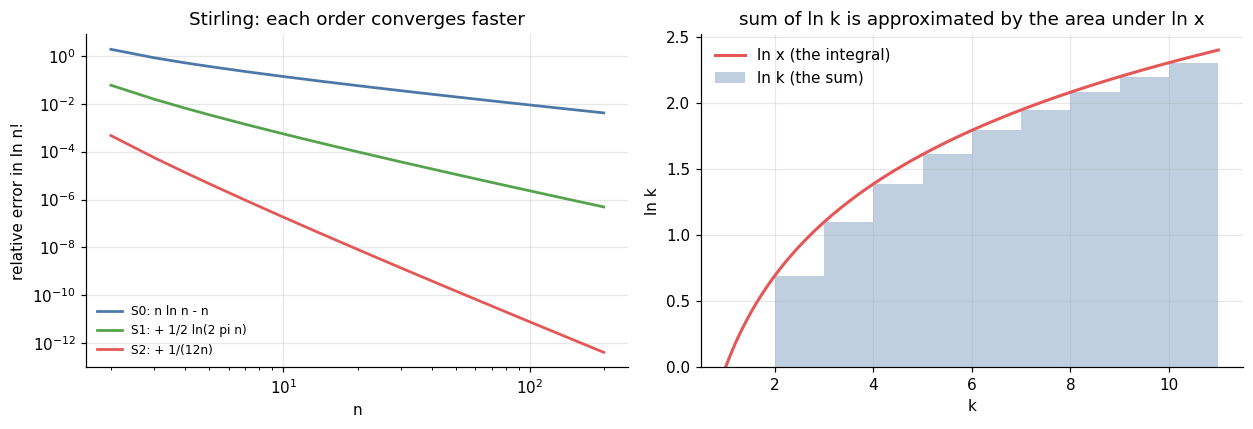

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
ns = np.arange(2, 200)
exact = np.array([math.lgamma(k+1) for k in ns])
for f, lab, c in [(S0, "S0: n ln n - n", "#4C78A8"),
                  (S1, "S1: + 1/2 ln(2 pi n)", "#54A24B"),
                  (S2, "S2: + 1/(12n)", "#E45756")]:
    ax[0].loglog(ns, np.abs(f(ns)-exact)/exact, color=c, label=lab)
ax[0].set_xlabel("n"); ax[0].set_ylabel("relative error in ln n!")
ax[0].set_title("Stirling: each order converges faster"); ax[0].legend(fontsize=8)
# the sum-of-logs vs the integral (area) picture at small n
k = np.arange(1, 11)
ax[1].bar(k, np.log(k), width=1.0, align="edge", alpha=0.35, color="#4C78A8", label="ln k (the sum)")
xx = np.linspace(1, 11, 300)
ax[1].plot(xx, np.log(xx), color="#E45756", lw=2, label="ln x (the integral)")
ax[1].set_xlabel("k"); ax[1].set_ylabel("ln k"); ax[1].legend()
ax[1].set_title("sum of ln k is approximated by the area under ln x")
plt.tight_layout(); plt.show()

## Summary

- $\ln n!=\sum_{k\le n}\ln k=\ln\Gamma(n+1)$; `math.lgamma` gives it exactly for any $n$.
- Stirling: $\ln n!\approx n\ln n-n+\tfrac12\ln(2\pi n)+\tfrac{1}{12n}$, derived from
  $\int_1^n\ln x\,dx=n\ln n-n+1$; the relative error falls order by order and is already $<10^{-4}$ at
  $n=100$ with the half-log term.
- Working in **log-space** dodges the overflow wall ($171!$ exceeds a float, $\ln N!$ never does),
  which is the only reason entropy is computable for Avogadro-scale matter.
- With Stirling, $\ln W=\ln N!-\sum_i\ln n_i!$ becomes the Gibbs entropy $-N\sum_i p_i\ln p_i$ -- the
  bridge back to the microstate and Boltzmann notebooks.

The same log-space discipline reappears in computer engineering as the log-sum-exp trick and
log-likelihoods: compute with logarithms, add instead of multiply, and overflow never happens.